#### 과일 데이터를 CNN으로 Image 분류

In [1]:
import numpy as np

In [2]:
fruits = np.load('../Data/fruits.npy')
fruits.shape

(300, 100, 100)

In [3]:
# Target 만들기
target = np.concatenate(
    [
        np.zeros(100), # apple
        np.ones(100), # pineapple
        np.full(100, 2) # banana
    ]
)
target.shape

(300,)

---
#### train 데이터와 test 데이터

In [30]:
train = fruits.reshape(-1, 100, 100, 1)
train.shape

(300, 100, 100, 1)

In [31]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [32]:
# 결과 확인
print(train_data.shape)
print(train_target.shape)
print(test_data.shape)
print(test_target.shape)

(240, 100, 100, 1)
(240,)
(60, 100, 100, 1)
(60,)


In [33]:
train_scaled = train_data / 255.0
train_scaled.shape

(240, 100, 100, 1)

#### CNN 만들기

In [13]:
from tensorflow import keras

In [75]:
model = keras.Sequential()

In [76]:
# 합성곱 층 만들기
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(100, 100, 1)
    )
)

In [77]:
model.add(
    keras.layers.MaxPooling2D(2)
)

In [78]:
model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same',
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

#### Dense 층

In [79]:
# 입력층
model.add(keras.layers.Flatten())

# 은닉층
model.add(keras.layers.Dense(1000, activation='relu'))

# Dropout층
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(100, activation='softmax'))

In [80]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1000)           │    40,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │       100,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,119,916 (153.05 MB)

 Trainable params: 40,119,916 (153.05 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_fruits_cnn.keras')
earlystopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=6,
    callbacks=[checkpoint_cb, earlystopping_cb]
)

Epoch 1/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4958 - loss: 2.2838   
Epoch 2/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 808ms/step - accuracy: 0.9917 - loss: 0.1677
Epoch 3/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 754ms/step - accuracy: 0.9958 - loss: 0.0262
Epoch 4/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 765ms/step - accuracy: 0.9958 - loss: 0.0065
Epoch 5/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 940ms/step - accuracy: 1.0000 - loss: 0.0028
Epoch 6/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 810ms/step - accuracy: 1.0000 - loss: 5.2313e-04


In [82]:
model.evaluate(train_scaled, train_target)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 1.5213e-04


[0.00015213001461233944, 1.0]

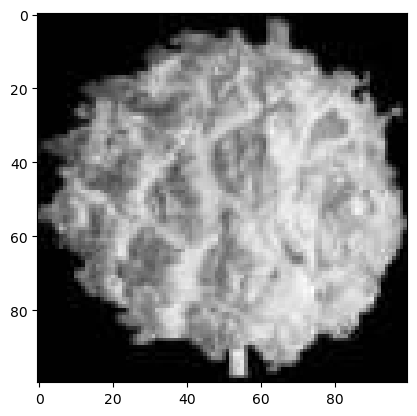

In [83]:
import matplotlib.pyplot as plt

plt.imshow(
    train_scaled[239].reshape(100, 100),
    cmap='gray'
)

plt.show()

In [84]:
pred = model.predict(train_scaled[:1])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


array([[3.36323712e-11, 1.45579250e-07, 9.99999881e-01, 1.25911321e-15,
        2.56274159e-16, 5.97318688e-16, 8.79284415e-16, 5.77421640e-15,
        4.86053975e-16, 1.09753542e-15, 2.18034526e-16, 5.06935772e-16,
        7.56269079e-16, 8.00912162e-16, 6.69731164e-16, 1.48615769e-16,
        1.51865821e-16, 1.83790559e-16, 2.63650757e-16, 2.74600352e-16,
        9.29360910e-17, 9.65340262e-16, 2.62922468e-17, 1.34671526e-15,
        7.71205764e-16, 5.58581065e-16, 4.32018514e-16, 2.70586412e-17,
        4.39574074e-16, 1.71018493e-16, 1.49376293e-15, 2.20372625e-15,
        5.57465629e-16, 1.89452005e-15, 1.95271154e-17, 7.37471830e-16,
        1.44960075e-15, 2.52855005e-16, 9.48693418e-16, 1.00487886e-16,
        9.27880191e-17, 5.00909398e-16, 4.37351195e-16, 3.44338142e-15,
        3.41587953e-16, 7.82427680e-16, 6.60826095e-16, 4.32782220e-16,
        1.41592357e-15, 3.34758571e-17, 1.77614999e-14, 1.99990435e-16,
        7.98121453e-16, 2.21815575e-16, 1.31239510e-16, 7.967499

In [85]:
import numpy as np
classes = [
    '사과',
    '파인애플',
    '바나나'
]

In [86]:
classes[np.argmax(pred)]

'바나나'

In [87]:
test_scaled = test_data.reshape(-1, 100, 100, 1) / 255.0

In [88]:
test_scaled.shape

(60, 100, 100, 1)

In [89]:
model.evaluate(test_scaled, test_target)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 3.0189e-04


[0.00030188882374204695, 1.0]